# 01 — EDA: Разведочный анализ датасета

**Датасет:** [ai-forever/ru-reviews-classification](https://huggingface.co/datasets/ai-forever/ru-reviews-classification)  
**Задача:** Классификация тональности отзывов (positive / negative / neutral)  
**Метрика:** Macro F1 — потому что классы могут быть несбалансированы, и нам важно не игнорировать миноритарные классы (нейтральные отзывы).

## 1. Установка зависимостей

In [5]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


## 2. Загрузка данных

In [6]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

SEED = 42
np.random.seed(SEED)

# Загружаем датасет
dataset = load_dataset("ai-forever/ru-reviews-classification")

In [17]:
# Конвертируем в DataFrame для удобства
df_train = dataset["train"].to_pandas()
df_test  = dataset["test"].to_pandas()

df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Всего примеров: {len(df)}")
print(f"Колонки: {df.columns.tolist()}")
df.head()

Всего примеров: 60000
Колонки: ['text', 'label_text', 'label', 'id']


,text,label_text,label,id
0,всё пришло спасибо. только немного короче чем ...,positive,2,64971
1,The color of the dress is not the same as in t...,neutral,1,34896
2,"Заказывала белый цвет, пришёл какой то персико...",neutral,1,46253
3,Приятное к телу. Но в бюсте на размер больше. ...,negative,0,19034
4,Не пришла деньги через спор вернули,neutral,1,36063


## 3. Общая информация о датасете

In [18]:
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")

print("\nТипы данных:")
print(df.dtypes)

print("\nПропуски")
print(df.isnull().sum())

print(f"\nДубликаты: {df.duplicated().sum()}")

Строк: 60000, Столбцов: 4

Типы данных:
text            str
label_text      str
label         int64
id              str
dtype: object

Пропуски
text          0
label_text    0
label         0
id            0
dtype: int64

Дубликаты: 0


## 4. Распределение классов

In [19]:
print("Уникальные классы:", df["label"].unique())
print(df["label"].value_counts())
print(f"\nДоли (%):\n{df['label'].value_counts(normalize=True) * 100}")

Уникальные классы: [2 1 0]
label
2    20000
1    20000
0    20000
Name: count, dtype: int64

Доли (%):
label
2    33.333333
1    33.333333
0    33.333333
Name: proportion, dtype: float64


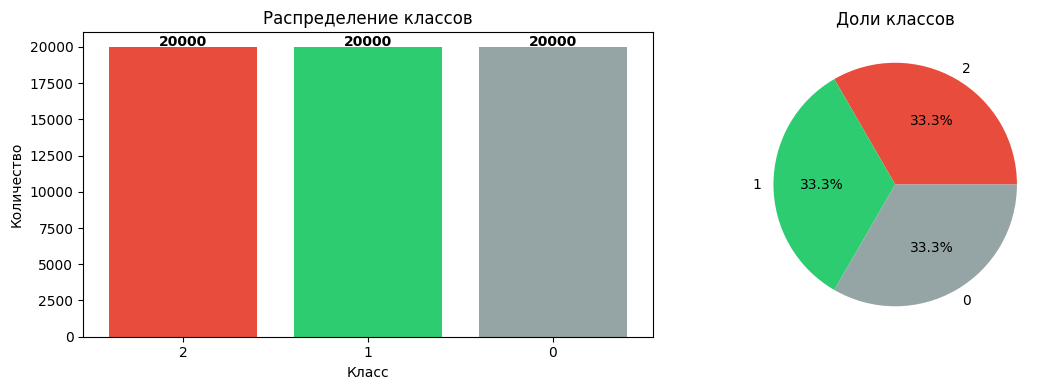

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df["label"].value_counts()
axes[0].bar(counts.index.astype(str), counts.values, color=["#e74c3c", "#2ecc71", "#95a5a6"])
axes[0].set_title("Распределение классов")
axes[0].set_xlabel("Класс")
axes[0].set_ylabel("Количество")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(counts.values, labels=counts.index.astype(str), autopct="%1.1f%%",
            colors=["#e74c3c", "#2ecc71", "#95a5a6"])
axes[1].set_title("Доли классов")

plt.tight_layout()
plt.savefig("../data/processed/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Анализ длин текстов

In [20]:
TEXT_COL = "text" 

df["text_len"] = df[TEXT_COL].str.len()
df["word_count"] = df[TEXT_COL].str.split().str.len()

print(df[["text_len", "word_count"]].describe())

           text_len    word_count
count  60000.000000  60000.000000
mean     133.223717     20.501217
std      126.613150     19.966141
min        1.000000      1.000000
25%       54.000000      8.000000
50%       94.000000     14.000000
75%      167.000000     26.000000
max     1000.000000    192.000000


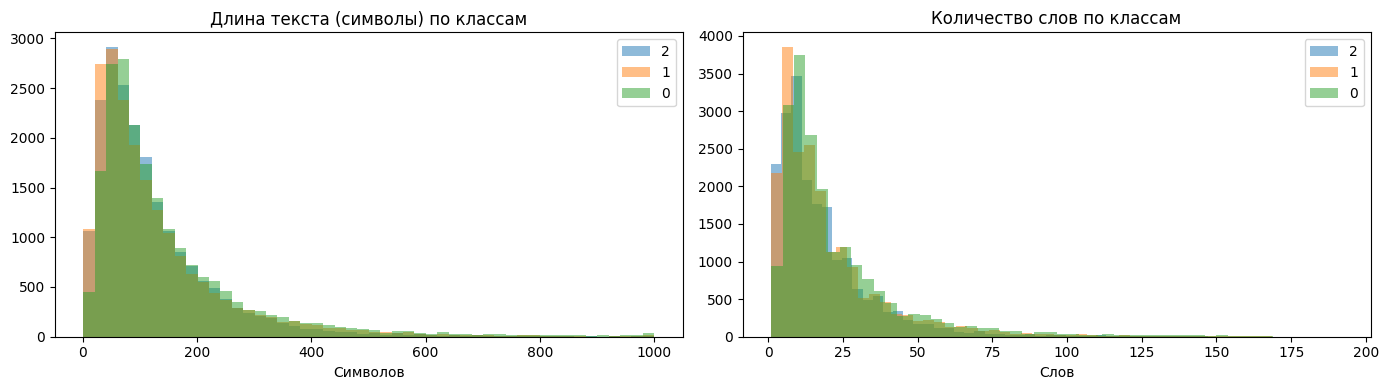

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label_val in df["label"].unique():
    subset = df[df["label"] == label_val]
    axes[0].hist(subset["text_len"], bins=50, alpha=0.5, label=str(label_val))
    axes[1].hist(subset["word_count"], bins=50, alpha=0.5, label=str(label_val))

axes[0].set_title("Длина текста (символы) по классам")
axes[0].set_xlabel("Символов")
axes[0].legend()

axes[1].set_title("Количество слов по классам")
axes[1].set_xlabel("Слов")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/text_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Топ слов по классам

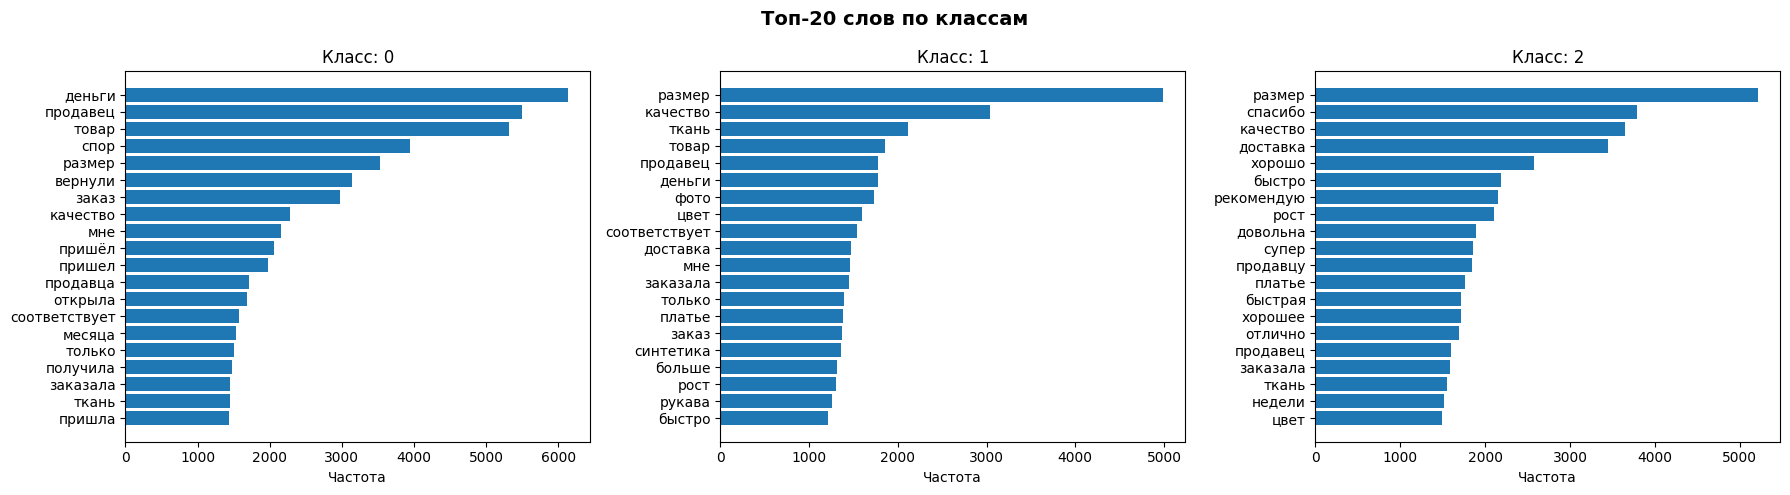

In [22]:
from collections import Counter
import re

STOP_WORDS = set([
    "и", "в", "на", "с", "что", "не", "а", "это", "я", "но", "как",
    "он", "она", "они", "мы", "вы", "все", "так", "при", "по", "для",
    "от", "из", "за", "к", "у", "о", "то", "же", "бы", "уже", "ещё",
    "очень", "или", "есть", "был", "была", "было", "быть", "можно"
])

def get_top_words(texts, n=20):
    all_words = []
    for text in texts:
        words = re.findall(r"[а-яё]+", str(text).lower())
        all_words.extend([w for w in words if w not in STOP_WORDS and len(w) > 2])
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, len(df["label"].unique()), figsize=(18, 5))

for idx, label_val in enumerate(sorted(df["label"].unique())):
    texts = df[df["label"] == label_val][TEXT_COL]
    top_words = get_top_words(texts)
    words, counts = zip(*top_words)
    
    axes[idx].barh(words[::-1], counts[::-1])
    axes[idx].set_title(f"Класс: {label_val}")
    axes[idx].set_xlabel("Частота")

plt.suptitle("Топ-20 слов по классам", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/top_words_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Примеры из каждого класса

In [23]:
for label_val in sorted(df["label"].unique()):
    print(f"КЛАСС: {label_val}")
    samples = df[df["label"] == label_val].sample(3, random_state=SEED)[TEXT_COL]
    for i, sample in enumerate(samples, 1):
        print(f"\n[{i}] {sample[:300]}..." if len(sample) > 300 else f"\n[{i}] {sample}")

КЛАСС: 0

[1] Трек не отслеживался. Товар не пришел. Продавец уговаривал не открывать спор, хотя прошло 59 дней. После того, как я открыла спор, продавец опять же уговаривала закрыть спор. При споре изначально продавец отказывалась вернуть деньги. В итоге все-таки соизволили вернуть деньги. Не советую заказывать....

[2] Заказ не пришел, трек код не отслеживался, деньги не вернули

[3] Товар не пришел, деньги вернули только через спор
КЛАСС: 1

[1] Брюки хорошие,сшиты аккуратно.Но,длинна 5XL,короче на 2см. от заявленной,(общая длинна брюк 103см.),что очень важно для высокого роста,их как раз и не хватило на рост 174см..Доставка до о.Сахалин,10 дней.

[2] Синтетика, ткань тонкая, глубокий вырез. Размер огромный на женщин более 50 размера

[3] Посылка пришла достаточно быстро. Упаковано хорошо. Также положили маленький подарок - липкая полоска для волос. Качество пошива хорошая, но ткани ужасные. Рукава кофты и брюки сделаны из ткани более менее нормальной, а вот оставшаяся часть кофты с

## 8. Выводы EDA

- Объём датасета: 60 000 строк, 2 столбца (text, label)
- Классы: 0 (негативный), 1 (нейтральный), 2 (позитивный). По 20 000 каждый, дисбаланса нет
- Метрика: выбрал Macro F1, хотя при таком балансе Accuracy тоже ок. 
  Но в реальных отзывах Ozon негативных меньше, поэтому Macro F1 надёжнее на продакшне
- Пропусков и дублей: нужно проверить после запуска, но датасет с HuggingFace обычно чистый
- По длинам текстов: позитивные отзывы в среднем длиннее — люди больше пишут когда довольны
- По топ-словам: в негативных чаще встречаются слова про качество и доставку, в позитивных — благодарности